In [1]:
import sys
sys.path.append('../src/')

import atom
import matplotlib.pyplot as plt
import mrcfile
import pdbtools
import potential
import torch
from tqdm import tqdm
from plotting_tools import plot3d, plot_slices

%load_ext autoreload
%autoreload 2

## Plotting functions

## Download PDB file

In [21]:
folder = '../pdb-data/'
filename = pdbtools.fetch_pdb_file("6e9d", output=folder)
filename

Assemblies available: 1
6e9d: Fetching default Biological Assembly 1
File already exists: ../pdb-data/6e9d-assembly1.cif


'../pdb-data/6e9d-assembly1.cif'

## Extract atomic coordinates and recenter onto (0,0,0)

In [22]:
# extracts raw coordinates for each atom in (x,y,z) order from pdb file
atomic_numbers, coords = pdbtools.get_atoms_and_coordinates_from_pdb(filename)
atomic_numbers.shape, coords.shape

/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain A is discontinuous at line 478080.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain B is discontinuous at line 478277.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain C is discontinuous at line 478476.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain D is discontinuous at line 478674.
  warnings.warn(
/scratch/loh/apps/miniforge3/envs/cryoem/lib/python3.11/site-packages/Bio/PDB/StructureBuilder.py:100: PDBConstructionWarning: WARNING: Chain E is discontinuous at line 478871.
  warnings.warn(
/scratch/loh/apps/miniforge3/e

(torch.Size([489900]), torch.Size([489900, 3]))

In [23]:
# elements in particle
print(set(atom.atom_symbol(atomic_numbers)))

{'O', 'N', 'S', 'H', 'C'}


In [24]:
coords.shape

torch.Size([489900, 3])

In [25]:
# recenters coordinates onto origin (0,0,0)
centered_coords = pdbtools.center_coordinates(coords)

## New grid sampling function

In [34]:
n = 256
dx = 1
x, y, z, X, Y, Z = potential.coordinate_grid_3d((n,n,n), (dx,dx,dx))

In [35]:
def voxelize_atoms(coords, grid_shape, voxel_size, device=None):
    """
    Convert atomic coordinates to a 3D binary grid (1s at nearest voxel, zeros elsewhere),
    assuming the center of the grid is at (nz//2, ny//2, nx//2).

    Args:
        coords: (N,3) tensor of atomic coordinates in physical units (x, y, z)
        grid_shape: tuple of ints (nx, ny, nz)
        voxel_size: tuple of floats (dx, dy, dz)
        device: optional, torch device

    Returns:
        grid: (nz, ny, nx) tensor with 1s at voxel positions of atoms
    """
    device = device or coords.device
    coords = coords.to(device)
    nx, ny, nz = grid_shape  # number of voxels along x, y, z

    # Compute the center of the grid in voxel units
    center_voxel = torch.tensor([nx//2, ny//2, nz//2], device=device)

    # Convert physical coordinates to voxel indices, shifting center
    indices = coords / torch.tensor(voxel_size, device=device)  # voxel units
    indices = indices + center_voxel  # shift so center is at middle voxel
    indices = torch.round(indices).long()

    # Mask atoms inside the grid
    mask = (
        (indices[:,0] >= 0) & (indices[:,0] < nx) &
        (indices[:,1] >= 0) & (indices[:,1] < ny) &
        (indices[:,2] >= 0) & (indices[:,2] < nz)
    )
    indices = indices[mask]

    # Create empty grid (z, y, x)
    grid = torch.zeros((nz, ny, nx), device=device, dtype=torch.float32)

    # Insert ones at valid voxel indices
    grid.index_put_(
        (indices[:,2], indices[:,1], indices[:,0]),
        torch.ones(indices.shape[0], device=device),
        accumulate=True
    )

    return grid

In [42]:
False | False

False

In [36]:
vol = voxelize_atoms(centered_coords, grid_shape=(n,n,n), voxel_size=(dx, dx, dx))

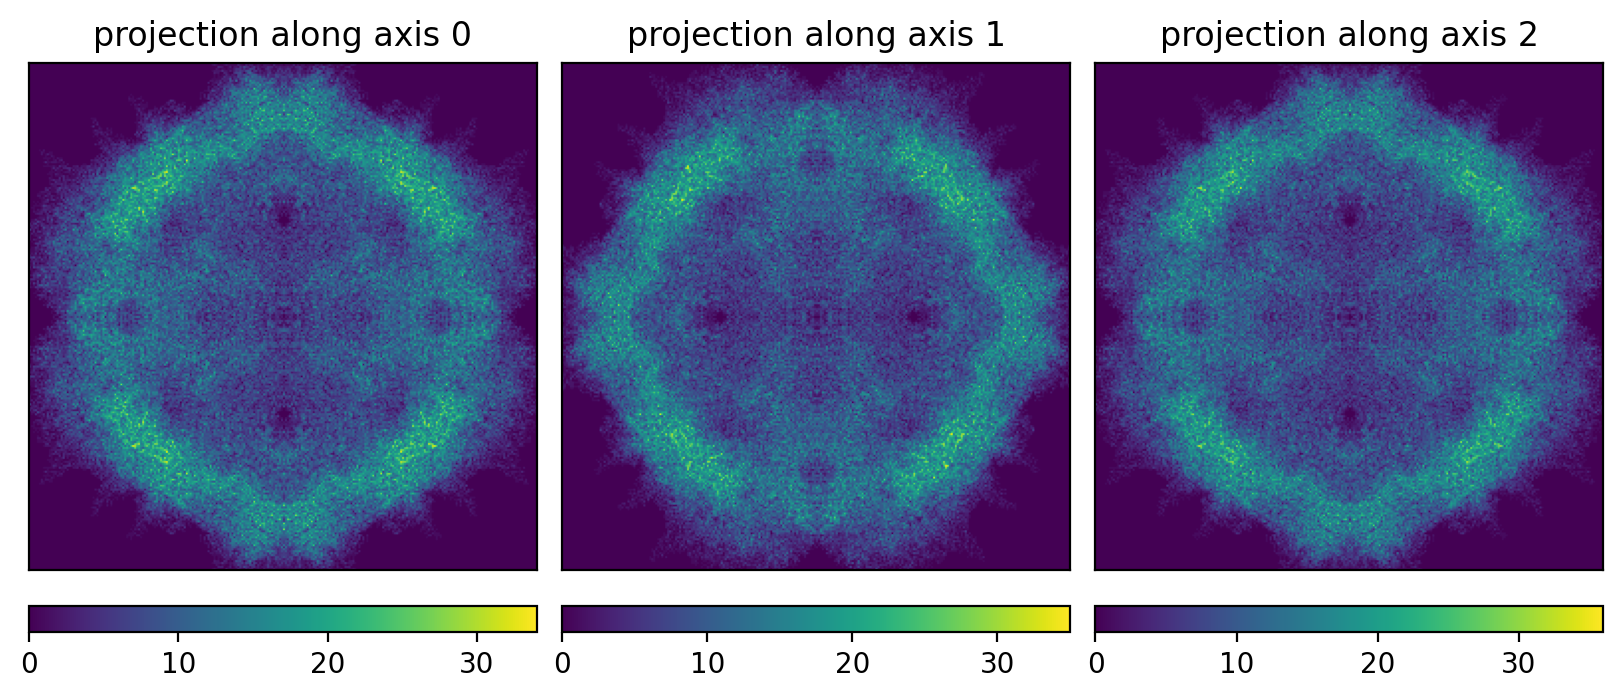

In [37]:
plot3d(vol)

## Compute volumetric potential from PDB (2D Projection, Snap)

In [8]:
dx = 1
n = 256
super_sampling_factor = 4
vol_snapped_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-2d",
)

46382it [00:06, 7524.49it/s]


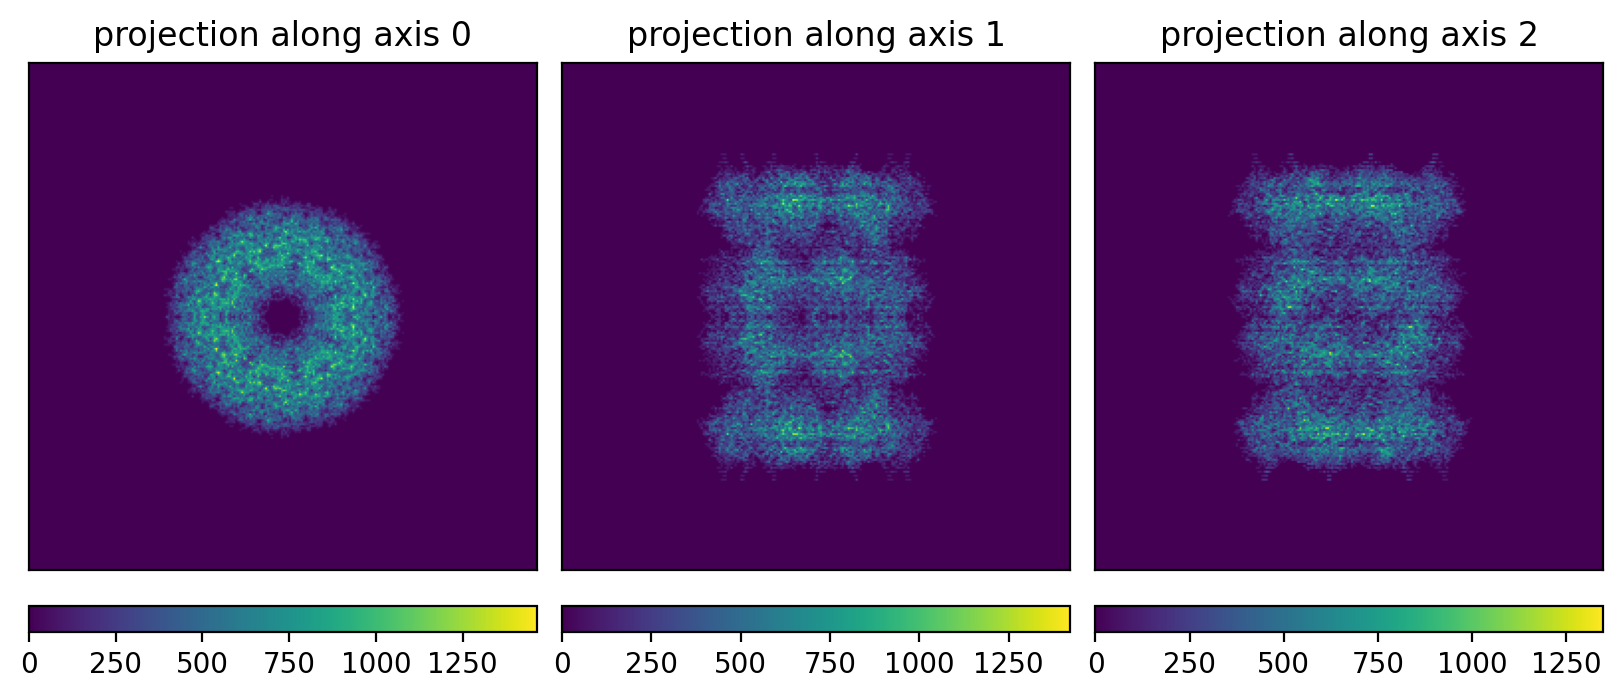

In [9]:
plot3d(vol_snapped_2d)

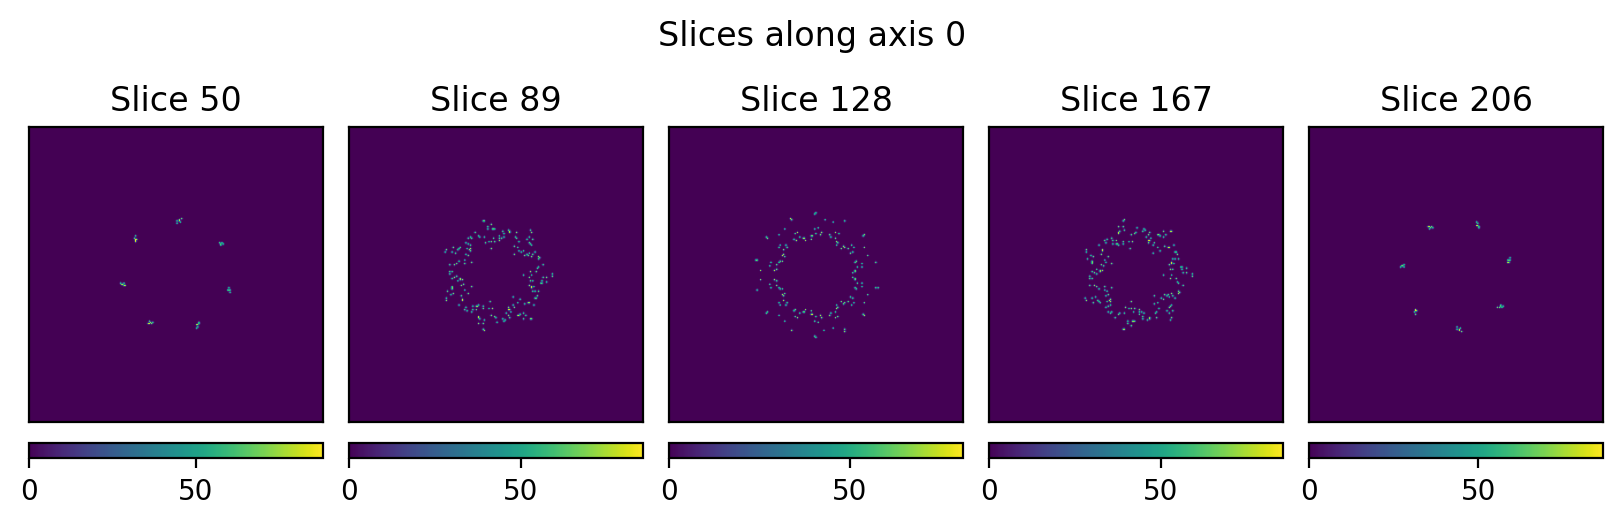

In [10]:
start_idx = 50
plot_slices(vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, Snap)

In [11]:
vol_snapped_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="snapped-3d",
)

46382it [00:06, 7148.60it/s]


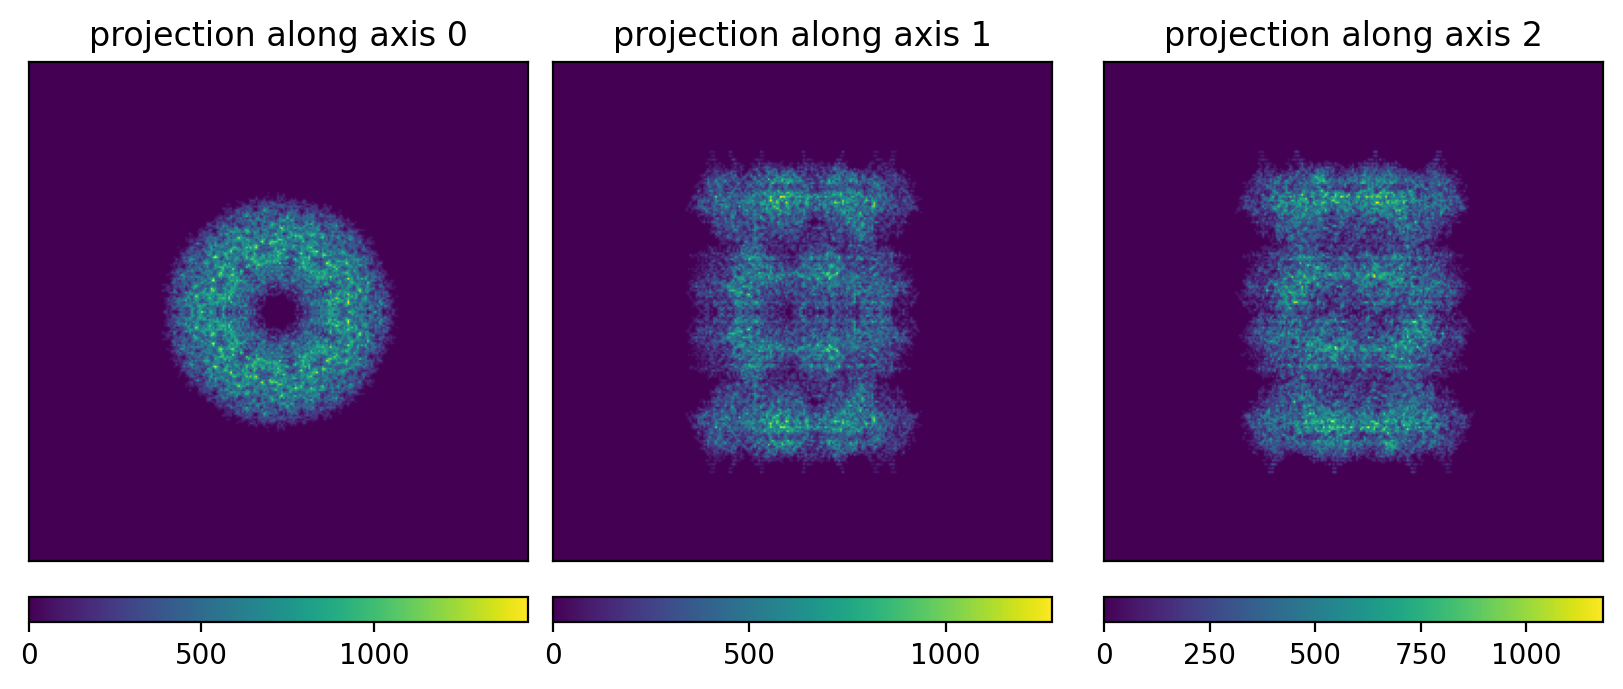

In [12]:
plot3d(vol_snapped_3d)

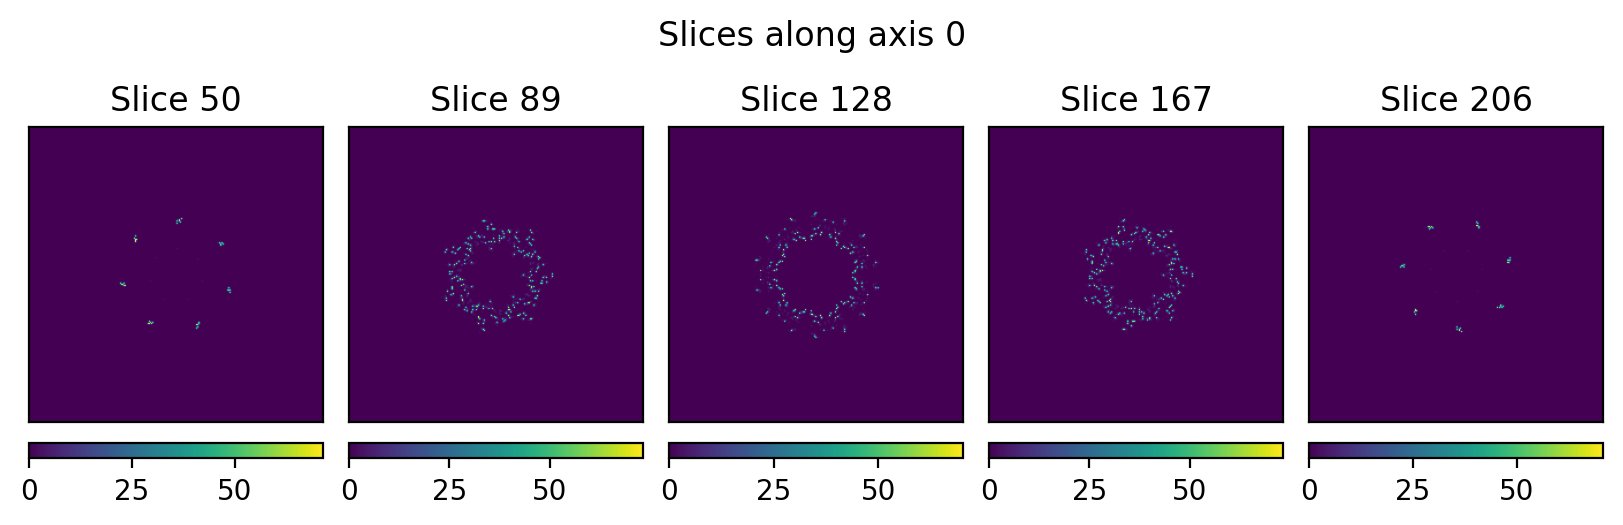

In [13]:
start_idx = 50
plot_slices(vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (2D Projection, snap-in-z only)

In [14]:
vol_2d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="2d",
)

46382it [03:14, 238.72it/s]


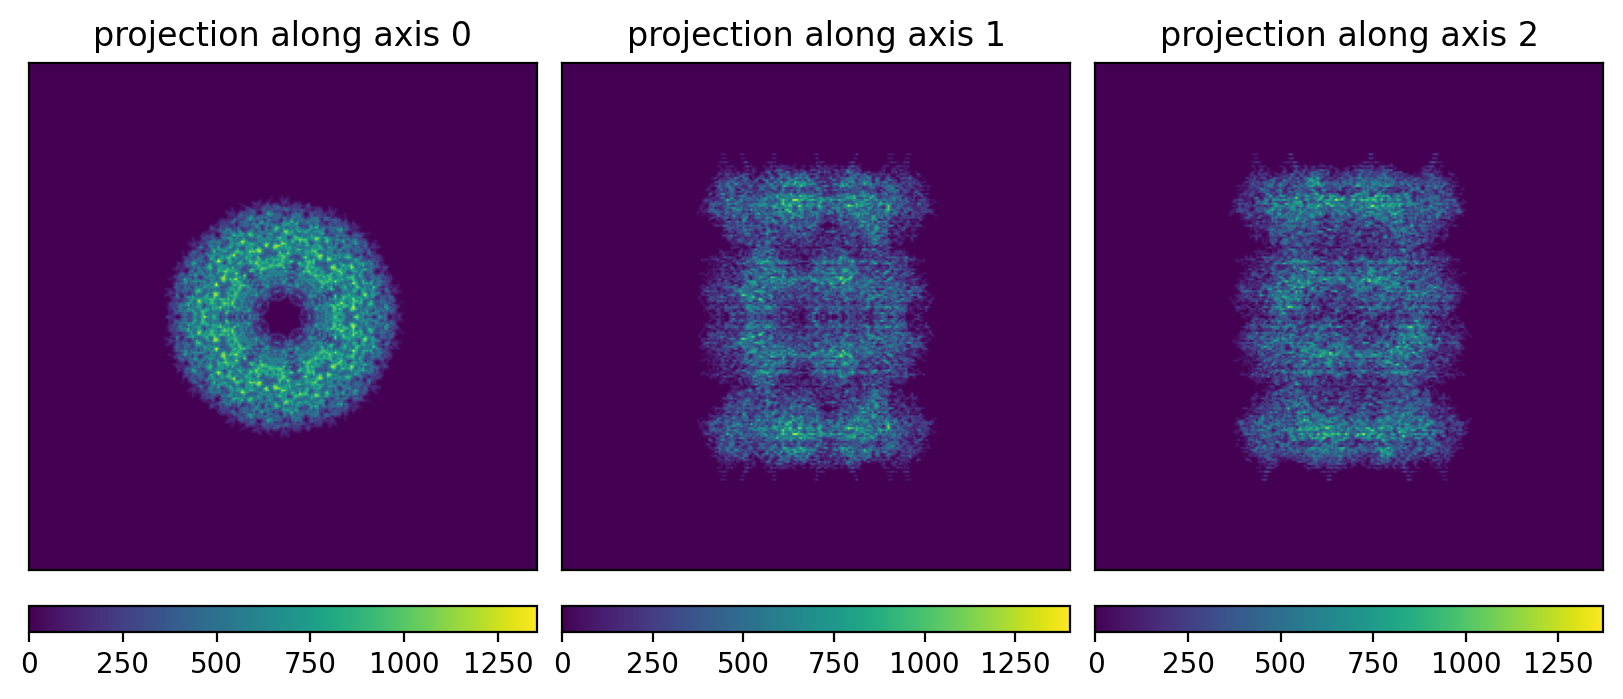

In [15]:
plot3d(vol_2d)

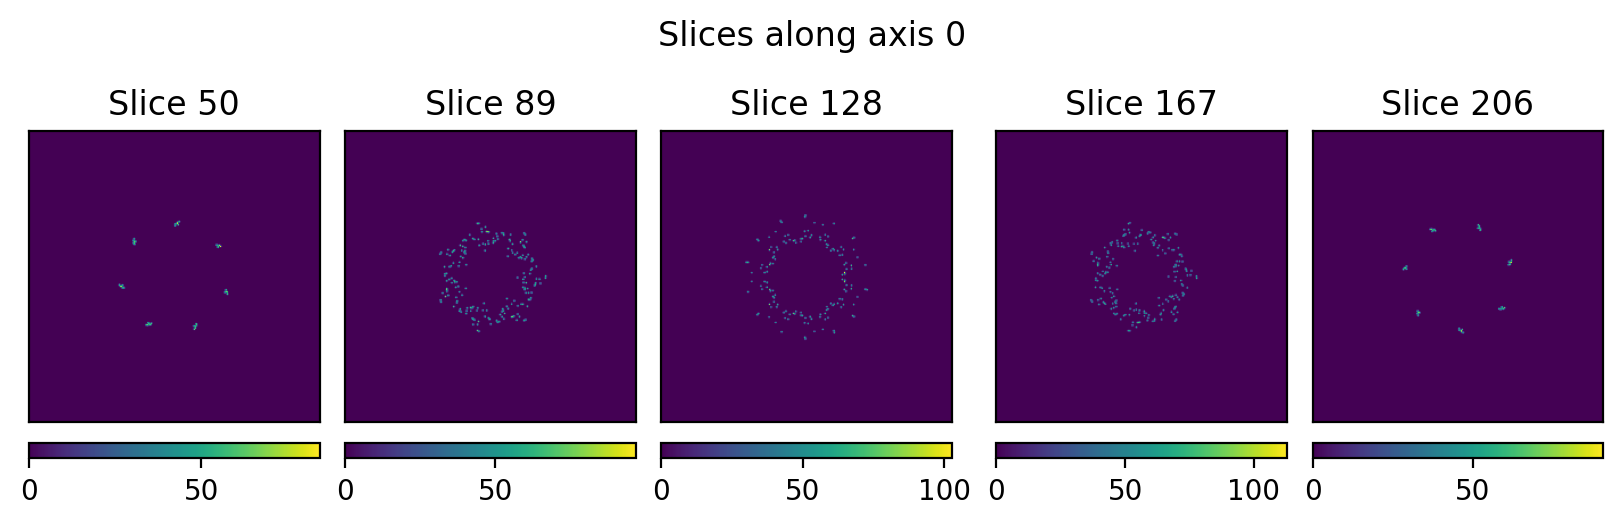

In [16]:
start_idx = 50
plot_slices(vol_2d, start_idx=start_idx, end_idx=n - start_idx)

## Compute volumetric potential from PDB (3D, no-snap)

In [17]:
vol_3d, occupancy = potential.build_potential_volume(
    atomic_numbers,
    centered_coords,
    (n, n, n),
    (dx, dx, dx),
    # atom_size_px=11,
    super_sampling_factor=super_sampling_factor,
    convention="relion",
    method="3d",
)

46382it [03:26, 225.01it/s]


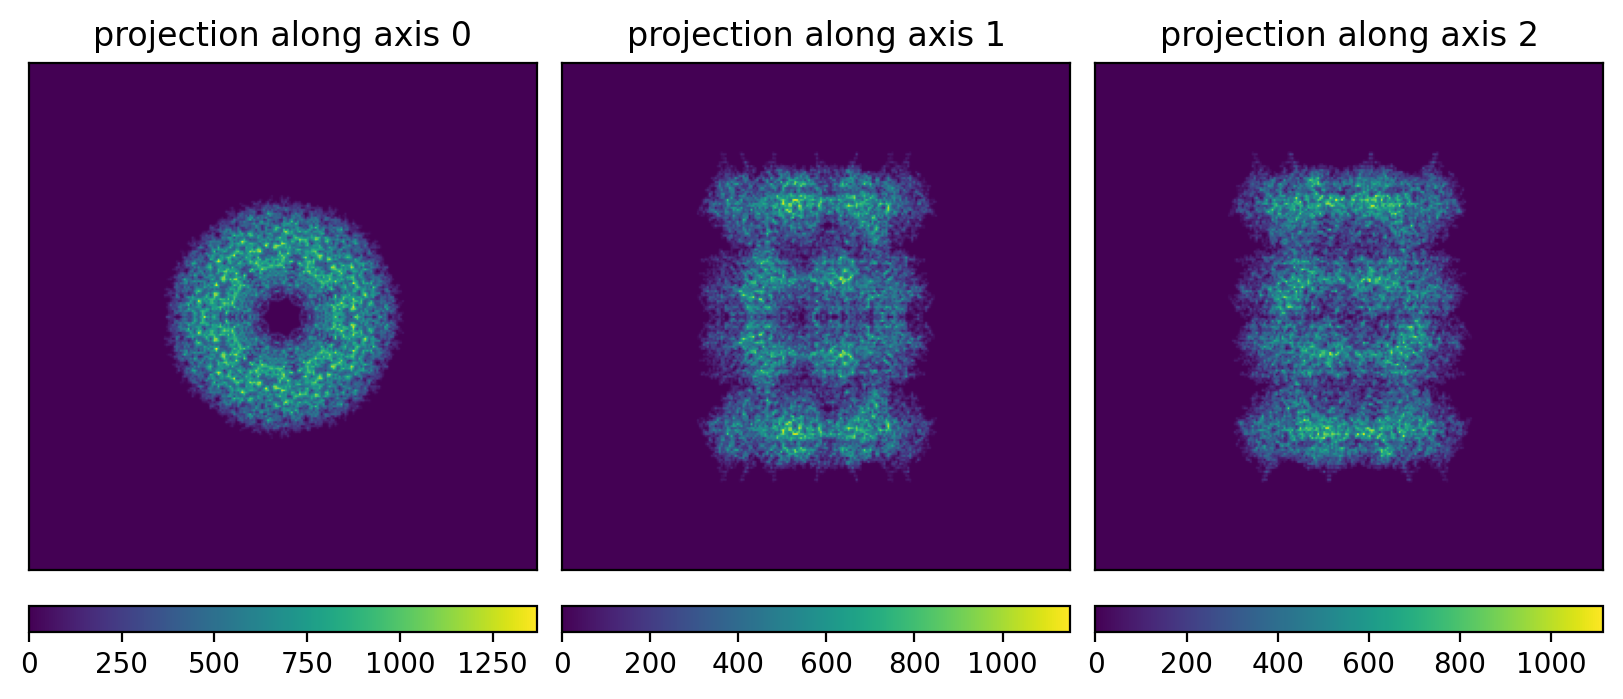

In [18]:
plot3d(vol_3d)

## Compare error between snap and no-snap

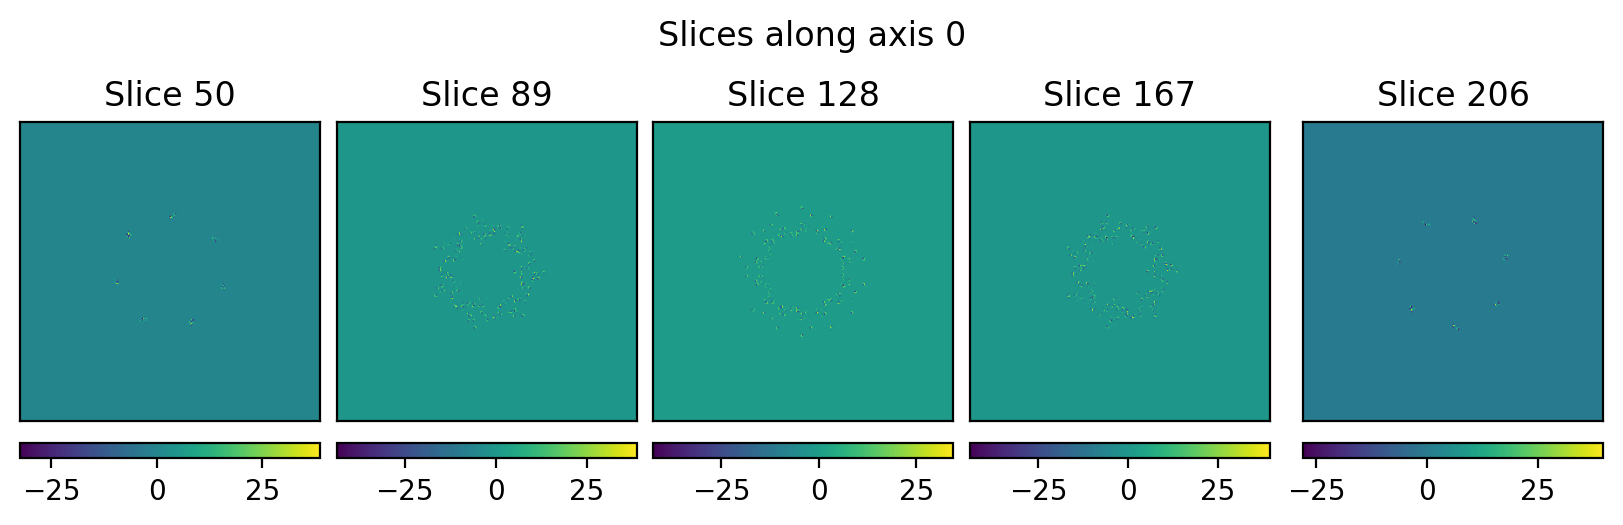

In [19]:
start_idx = 50
plot_slices(vol_2d - vol_snapped_2d, start_idx=start_idx, end_idx=n - start_idx)

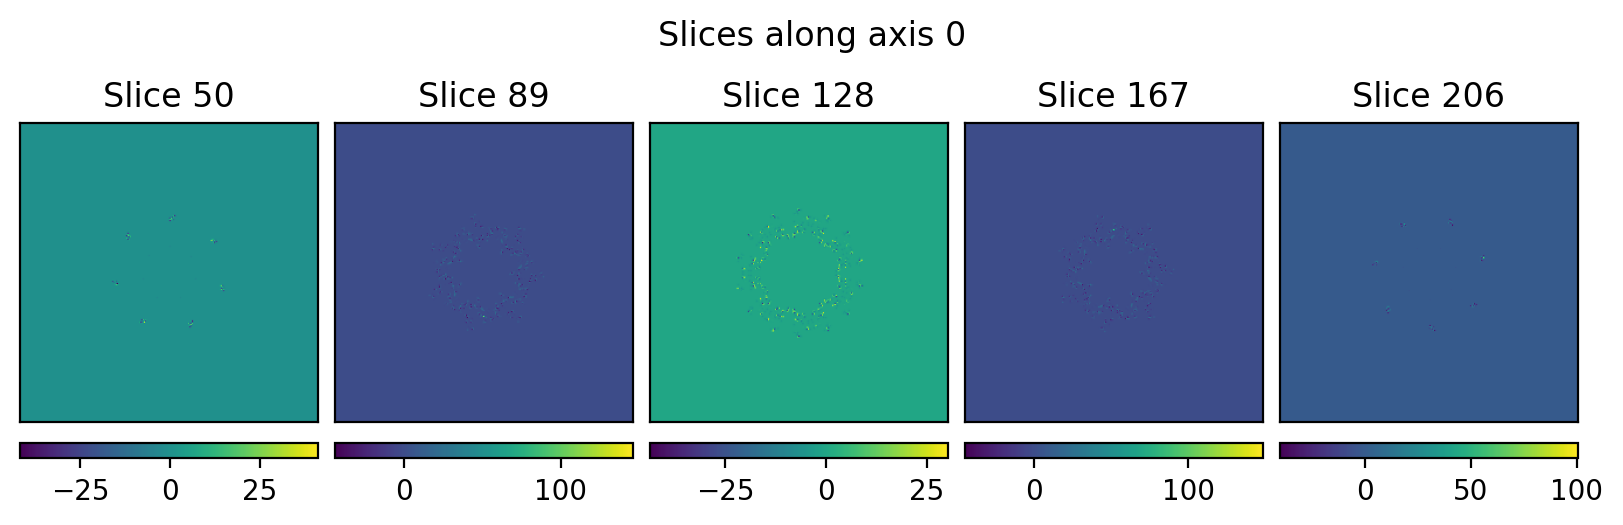

In [20]:
start_idx = 50
plot_slices(vol_3d - vol_snapped_3d, start_idx=start_idx, end_idx=n - start_idx)